## SETUP & KONFIGURASI

In [38]:
# pip install clickhouse-connect==0.15.1 pandas==3.0.2 numpy==2.1.3 scikit-learn==1.8.0 matplotlib==3.9.3 seaborn==0.13.2 scipy==1.17.1

In [39]:
import clickhouse_connect
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

# Tampilkan versi semua library (WAJIB)
print("=== VERSI LIBRARY ===")
print(f"clickhouse-connect : {clickhouse_connect.__version__}")
print(f"pandas             : {pd.__version__}")
print(f"numpy              : {np.__version__}")
print(f"scikit-learn       : {sklearn.__version__}")
print(f"matplotlib         : {matplotlib.__version__}")
print(f"seaborn            : {sns.__version__}")
print(f"scipy              : {scipy.__version__}")

# Variabel konfigurasi koneksi
HOST      = 'overproficiently-unbenevolent-gregoria.ngrok-free.dev'
PORT      = 443
USERNAME  = 'mahasiswa'
PASSWORD  = 'bigdata123'
DATABASE  = 'praktikum'
TABLE_SRC = 'final_pipeline'
TABLE_DST = 'clustering_results'
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
print(f"\nRandom seed ditetapkan: {RANDOM_SEED}")

# Koneksi ke ClickHouse
print("\nMenghubungkan ke ClickHouse...")
client = clickhouse_connect.get_client(
    host=HOST,
    port=PORT,
    username=USERNAME,
    password=PASSWORD,
    database=DATABASE,
    secure=True
)
print(f"Koneksi berhasil! Versi server: {client.server_version}")

=== VERSI LIBRARY ===
clickhouse-connect : <module 'clickhouse_connect.__version__' from 'd:\\ASUS\\Documents\\code\\bigData\\HandsOn\\.venv\\Lib\\site-packages\\clickhouse_connect\\__version__.py'>
pandas             : 3.0.2
numpy              : 2.4.4
scikit-learn       : 1.8.0
matplotlib         : 3.10.9
seaborn            : 0.13.2
scipy              : 1.17.1

Random seed ditetapkan: 42

Menghubungkan ke ClickHouse...
Koneksi berhasil! Versi server: 26.3.9.8


## EXPORT DATA HASIL PREPROCESSING KE PANDAS

In [40]:
# Query agregasi per perusahaan — fitur statistik pola publikasi
# Keputusan: clustering dilakukan pada level perusahaan (361 entitas unik)
# Alasan: kolom teks tidak bisa langsung di-cluster tanpa NLP;
#         fitur waktu (hour, minute, day_of_week, is_weekend) merepresentasikan
#         pola perilaku publikasi berita setiap perusahaan.

print("Mengambil dan mengagregasi data dari ClickHouse (dengan Cyclical Transform)...")

query = """
    SELECT
        cik_clean,
        cleaned_company,

        -- Volume publikasi asli (nanti dilogaritma di Python)
        count(*) AS total_articles,

        -- Transformasi Sirkular untuk Jam (0-23)
        avg(sin(hour * 2 * pi() / 24)) AS avg_sin_hour,
        avg(cos(hour * 2 * pi() / 24)) AS avg_cos_hour,
        stddevPop(hour) AS std_hour,

        -- Pola menit dibiarkan linear karena 0 dan 59 jarang punya signifikansi siklus di publikasi artikel
        avg(minute) AS avg_minute,
        stddevPop(minute) AS std_minute,

        -- Transformasi Sirkular untuk Hari (1-7)
        avg(sin(day_of_week * 2 * pi() / 7)) AS avg_sin_day_of_week,
        avg(cos(day_of_week * 2 * pi() / 7)) AS avg_cos_day_of_week,
        stddevPop(day_of_week) AS std_day_of_week,

        -- Proporsi publikasi di akhir pekan
        avg(is_weekend) AS ratio_weekend

    FROM praktikum.final_pipeline
    GROUP BY cik_clean, cleaned_company
    ORDER BY total_articles DESC
"""

df = client.query_df(query)

print(f"✅ Data berhasil diambil!")
print(f"   Jumlah perusahaan (baris) : {df.shape[0]}")
print(f"   Jumlah fitur (kolom)      : {df.shape[1]}")
print(f"   Ukuran DataFrame          : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\nKolom: {list(df.columns)}")
print(f"\nSample data:")
print(df.head())
print(f"\nStatistik deskriptif:")
print(df.describe())

Mengambil dan mengagregasi data dari ClickHouse (dengan Cyclical Transform)...
✅ Data berhasil diambil!
   Jumlah perusahaan (baris) : 361
   Jumlah fitur (kolom)      : 12
   Ukuran DataFrame          : 44.31 KB

Kolom: ['cik_clean', 'cleaned_company', 'total_articles', 'avg_sin_hour', 'avg_cos_hour', 'std_hour', 'avg_minute', 'std_minute', 'avg_sin_day_of_week', 'avg_cos_day_of_week', 'std_day_of_week', 'ratio_weekend']

Sample data:
    cik_clean         cleaned_company  total_articles  avg_sin_hour  \
0  0001867066    journey medical corp           27099      0.372695   
1  0001571996  dell technologies inc.           27035      0.250184   
2  0001729944     imac holdings, inc.           24068      0.085450   
3  0001596532   arista networks, inc.           22487      0.248955   
4  0001839133            ir-med, inc.           22419      0.450748   

   avg_cos_hour  std_hour  avg_minute  std_minute  avg_sin_day_of_week  \
0      0.233495  5.456224   22.124986   16.575314          

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. EKSPLORASI (EDA)
print("=== STATISTIK DESKRIPTIF ===")
print(df.describe().round(4))

# Cek Korelasi (Bisa di-uncomment jika ingin melihat visualisasinya)
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
# plt.title('Korelasi Antar Fitur (Sirkular)')
# plt.show()

# 2. FEATURE ENGINEERING
# Transformasi skewness untuk volume artikel
df['total_articles_log'] = np.log1p(df['total_articles'])

# Tidak perlu df.drop() karena kolom redundan sudah tidak ditarik dari SQL
df_model = df.copy()

# 3. PENYIAPAN FITUR & IMPUTASI
feature_cols = [
    'total_articles_log',
    'avg_sin_hour',
    'avg_cos_hour',
    'std_hour',
    'avg_minute',
    'std_minute',
    'avg_sin_day_of_week',
    'avg_cos_day_of_week',
    'std_day_of_week',
    'ratio_weekend'
]

df_identity = df_model[['cik_clean', 'cleaned_company']].copy()
X = df_model[feature_cols].copy()

# Isi NaN pada std (untuk perusahaan dengan 1 artikel)
X = X.fillna(0)

# 4. SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("\n=== HASIL SCALING (StandardScaler) ===")
print("Statistik setelah scaling (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(4))

=== STATISTIK DESKRIPTIF ===
       total_articles  avg_sin_hour  avg_cos_hour  std_hour  avg_minute  \
count        361.0000      361.0000      361.0000  361.0000    361.0000   
mean        6079.6676       -0.0794       -0.0149    5.9650     22.0173   
std         6991.0218        0.2559        0.3096    1.4076      3.8262   
min            1.0000       -0.9659       -0.9830    0.0000      0.0000   
25%          120.0000       -0.2228       -0.2021    5.5648     21.1351   
50%         2353.0000       -0.0908       -0.0682    6.2330     22.2824   
75%        12103.0000        0.0854        0.1124    6.6949     22.8938   
max        27099.0000        0.8736        0.9659   10.3709     45.0000   

       std_minute  avg_sin_day_of_week  avg_cos_day_of_week  std_day_of_week  \
count    361.0000             361.0000             361.0000         361.0000   
mean      16.2174               0.0521              -0.1968           1.6573   
std        2.4479               0.1866               0.

## PRE-PROCESSING DI PYTHON

### 1. Pilih fitur untuk clustering

In [42]:
# Keputusan: kolom cik_clean & cleaned_company digunakan sebagai
# identitas, BUKAN sebagai fitur model (teks tidak di-encode
# karena tidak merepresentasikan pola perilaku secara numerik)

# 1. PERUBAHAN: Daftar fitur diperbarui (memakai log, membuang yang redundan)
feature_cols = [
    'total_articles_log',
    'avg_sin_hour',
    'avg_cos_hour',
    'std_hour',
    'avg_minute',
    'std_minute',
    'avg_sin_day_of_week',
    'avg_cos_day_of_week',
    'std_day_of_week',
    'ratio_weekend'
]

# 2. Mengambil data dari df_model
df_identity = df_model[['cik_clean', 'cleaned_company']].copy()

# Matrix fitur
X = df_model[feature_cols].copy()

print("=== 4.1 FITUR YANG DIGUNAKAN ===")
print(f"Jumlah fitur  : {len(feature_cols)}")
print(f"Jumlah sampel : {X.shape[0]}")
print(f"\nCek missing values setelah agregasi:")
print(X.isnull().sum())

# Isi NaN pada std (perusahaan dengan 1 artikel → std = NaN → 0)
X = X.fillna(0)
print(f"\nMissing values setelah fillna(0): {X.isnull().sum().sum()}")

=== 4.1 FITUR YANG DIGUNAKAN ===
Jumlah fitur  : 10
Jumlah sampel : 361

Cek missing values setelah agregasi:
total_articles_log     0
avg_sin_hour           0
avg_cos_hour           0
std_hour               0
avg_minute             0
std_minute             0
avg_sin_day_of_week    0
avg_cos_day_of_week    0
std_day_of_week        0
ratio_weekend          0
dtype: int64

Missing values setelah fillna(0): 0


### 2 - Scaling dengan StandardScaler

In [43]:
from sklearn.preprocessing import StandardScaler

# Keputusan: StandardScaler dipakai karena clustering berbasis
# jarak (K-Means, DBSCAN) sensitif terhadap skala fitur.
# total_articles sudah ditransformasi (log) sehingga distribusinya lebih baik.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X di sini sudah berisi fitur final yang bersih
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("\n=== 4.2 HASIL SCALING (StandardScaler) ===")
print("Statistik setelah scaling (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(4))


=== 4.2 HASIL SCALING (StandardScaler) ===
Statistik setelah scaling (mean ≈ 0, std ≈ 1):
       total_articles_log  avg_sin_hour  avg_cos_hour  std_hour  avg_minute  \
count            361.0000      361.0000      361.0000  361.0000    361.0000   
mean               0.0000        0.0000        0.0000   -0.0000     -0.0000   
std                1.0014        1.0014        1.0014    1.0014      1.0014   
min               -2.3701       -3.4695       -3.1315   -4.2437     -5.7623   
25%               -0.8256       -0.5613       -0.6056   -0.2847     -0.2309   
50%                0.2918       -0.0447       -0.1722    0.1907      0.0694   
75%                0.9082        0.6450        0.4120    0.5193      0.2294   
max                1.2117        3.7292        3.1730    3.1346      6.0150   

       std_minute  avg_sin_day_of_week  avg_cos_day_of_week  std_day_of_week  \
count    361.0000             361.0000             361.0000         361.0000   
mean       0.0000              -0.000

### 3 - PCA untuk reduksi dimensi (visualisasi 2D)

In [44]:

# Keputusan: PCA 2 komponen digunakan KHUSUS untuk visualisasi

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

print("\n=== 4.3 HASIL PCA ===")
print(f"Explained variance ratio : {pca.explained_variance_ratio_}")
print(f"Total variance explained : {sum(pca.explained_variance_ratio_):.2%}")
print(f"Shape X_pca              : {X_pca.shape}")

# Simpan PCA ke DataFrame dengan identitas
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca = pd.concat([df_identity.reset_index(drop=True), df_pca], axis=1)

print(f"\nSample df_pca:")
print(df_pca.head())


=== 4.3 HASIL PCA ===
Explained variance ratio : [0.36172215 0.1631508 ]
Total variance explained : 52.49%
Shape X_pca              : (361, 2)

Sample df_pca:
    cik_clean         cleaned_company       PC1       PC2
0  0001867066    journey medical corp  2.302305 -0.965512
1  0001571996  dell technologies inc.  2.509172 -0.845589
2  0001729944     imac holdings, inc.  2.454927 -0.584762
3  0001596532   arista networks, inc.  2.537507 -0.999198
4  0001839133            ir-med, inc.  1.794027 -1.044709


### 4 - Ringkasan variabel

In [45]:
print("\n=== RINGKASAN OUTPUT ===")
print(f"X_scaled  → shape {X_scaled.shape}  | input model clustering")
print(f"X_pca     → shape {X_pca.shape}     | visualisasi scatter 2D")
print(f"df        → shape {df.shape}        | DataFrame lengkap")
print(f"df_pca    → shape {df_pca.shape}    | PCA + identitas perusahaan")
print(f"RANDOM_SEED = {RANDOM_SEED}")
print("\n✅ Pre-processing selesai! Data siap untuk modeling (Orang 2).")


=== RINGKASAN OUTPUT ===
X_scaled  → shape (361, 10)  | input model clustering
X_pca     → shape (361, 2)     | visualisasi scatter 2D
df        → shape (361, 13)        | DataFrame lengkap
df_pca    → shape (361, 4)    | PCA + identitas perusahaan
RANDOM_SEED = 42

✅ Pre-processing selesai! Data siap untuk modeling (Orang 2).


### PEMODELAN ML (CLUSTERING)

#### K-MEANS

Mencari nilai K optimal...


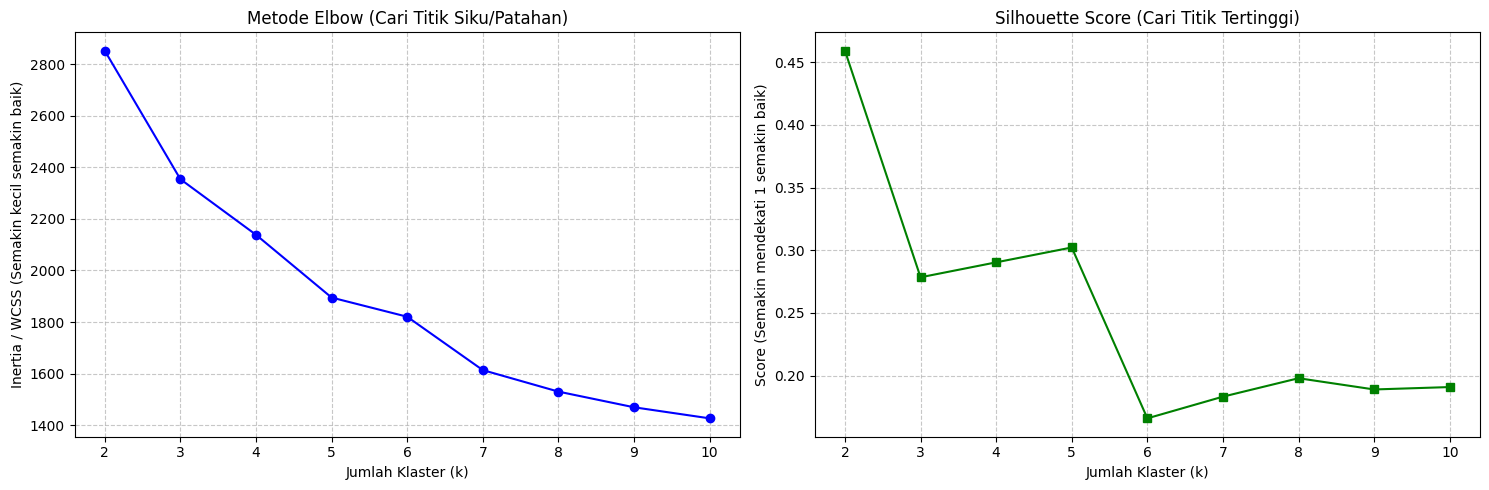

Berdasarkan Silhouette Score, K terbaik adalah: 2 dengan skor 0.4591


In [46]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Mencari nilai K optimal...")

# Menyimpan riwayat metrik untuk setiap pengujian K
inertia_values = []
silhouette_scores = []

# Kita akan menguji jumlah klaster dari 2 hingga 10
k_range = range(2, 11)

for k in k_range:
    # 1. Latih model dengan jumlah klaster K
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels_test = kmeans_test.fit_predict(X_scaled)
    
    # 2. Simpan nilai Inertia (untuk Metode Elbow)
    inertia_values.append(kmeans_test.inertia_)
    
    # 3. Simpan nilai Silhouette
    sil_score = silhouette_score(X_scaled, labels_test)
    silhouette_scores.append(sil_score)

# VISUALISASI GRAFIK EVALUASI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metode Elbow (Inertia)
ax1.plot(k_range, inertia_values, marker='o', linestyle='-', color='b')
ax1.set_title('Metode Elbow (Cari Titik Siku/Patahan)')
ax1.set_xlabel('Jumlah Klaster (k)')
ax1.set_ylabel('Inertia / WCSS (Semakin kecil semakin baik)')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Silhouette Score (Cari Titik Tertinggi)')
ax2.set_xlabel('Jumlah Klaster (k)')
ax2.set_ylabel('Score (Semakin mendekati 1 semakin baik)')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Mencetak skor tertingginya agar mudah dibaca
best_k_sil = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Berdasarkan Silhouette Score, K terbaik adalah: {best_k_sil} dengan skor {max(silhouette_scores):.4f}")

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Berdasarkan hasil evaluasi visual (Silhouette Score tertinggi), K optimal adalah 2
optimal_k = 2

print(f"Melatih model K-Means final dengan n_clusters = {optimal_k}...")

# 1. Inisialisasi model K-Means Final
kmeans_final = KMeans(
    n_clusters=optimal_k, 
    random_state=RANDOM_SEED,
    n_init="auto"
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

# MASALAH SEBELUMNYA: Kamu harus memasukkan label ini ke df_model agar bisa dipanggil
df_model['KMeans_Cluster'] = kmeans_labels

print("K-Means berhasil dijalankan pada data yang telah dibersihkan!")

# 2. Latih model dan dapatkan label final untuk 361 perusahaan
kmeans_labels_final = kmeans_final.fit_predict(X_scaled)

# 3. Evaluasi metrik untuk dilaporkan
final_sil_score = silhouette_score(X_scaled, kmeans_labels_final)
final_dbi_score = davies_bouldin_score(X_scaled, kmeans_labels_final)

print("\n=== HASIL FINAL K-MEANS ===")
print(f"Jumlah Klaster (K)   : {optimal_k}")
print(f"Silhouette Score     : {final_sil_score:.4f} (Mendekati 1 = Sangat Baik)")
print(f"Davies-Bouldin Index : {final_dbi_score:.4f} (Mendekati 0 = Sangat Baik)")

# 4. Integrasi Output: Simpan hasil ke dataframe milik
df_pca['KMeans_Cluster'] = kmeans_labels_final

# 5. Cek distribusi anggotanya (Berapa perusahaan di klaster 0, berapa di klaster 1)
print("\nDistribusi jumlah perusahaan per klaster:")
print(df_pca['KMeans_Cluster'].value_counts())

print("\nContoh 10 data pertama dengan label final:")
print(df_pca[['cleaned_company', 'KMeans_Cluster']].head(10))

# Sinkronisasi ke df utama (untuk Cell Evaluasi)
df["KMeans_Cluster"] = kmeans_labels_final


Melatih model K-Means final dengan n_clusters = 2...
K-Means berhasil dijalankan pada data yang telah dibersihkan!

=== HASIL FINAL K-MEANS ===
Jumlah Klaster (K)   : 2
Silhouette Score     : 0.4591 (Mendekati 1 = Sangat Baik)
Davies-Bouldin Index : 1.5220 (Mendekati 0 = Sangat Baik)

Distribusi jumlah perusahaan per klaster:
KMeans_Cluster
0    308
1     53
Name: count, dtype: int64

Contoh 10 data pertama dengan label final:
                  cleaned_company  KMeans_Cluster
0            journey medical corp               0
1          dell technologies inc.               0
2             imac holdings, inc.               0
3           arista networks, inc.               0
4                    ir-med, inc.               0
5                  doordash, inc.               0
6                    coca cola co               0
7  sci engineered materials, inc.               0
8                     infosys ltd               0
9                      deere & co               0


#### Agglomerative

In [48]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# GUARD: Pastikan X_scaled tersedia

try:
    _ = X_scaled.shape
    print(f"✅ X_scaled ditemukan: shape {X_scaled.shape}")
except NameError:
    print("❌ X_scaled tidak ditemukan. Menjalankan ulang preprocessing...")
    feature_cols = [
        'total_articles_log',
        'avg_hour',
        'ratio_off_hours',
        'ratio_weekend',
        'avg_day_of_week'
    ]
    available = [c for c in feature_cols if c in df.columns]
    missing   = [c for c in feature_cols if c not in df.columns]
    print(f"   Kolom tersedia : {available}")
    print(f"   Kolom tidak ada: {missing}")
    X = df[available].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"✅ X_scaled berhasil dibuat ulang: shape {X_scaled.shape}")

print("\n=== MEMULAI PELATIHAN MODEL ===")

# 2. AGGLOMERATIVE CLUSTERING
agglo     = AgglomerativeClustering(n_clusters=2, linkage='ward')
dbscan_labels_final = agglo.fit_predict(X_scaled)

df['Agglo_Cluster']     = dbscan_labels_final
df_pca['Agglo_Cluster'] = dbscan_labels_final

print(f"✅ Agglomerative selesai")
print(f"   Distribusi: {dict(pd.Series(dbscan_labels_final).value_counts().sort_index())}")

# VALIDASI SINKRONISASI
assert len(df) == len(df_pca), "❌ Jumlah baris df dan df_pca tidak sama!"
print(f"\n✅ Label tersinkronisasi | df: {df.shape} | df_pca: {df_pca.shape}")
print("✅ Cell 1 selesai. Lanjutkan ke Cell 2 untuk evaluasi.")

✅ X_scaled ditemukan: shape (361, 10)

=== MEMULAI PELATIHAN MODEL ===
✅ Agglomerative selesai
   Distribusi: {0: np.int64(266), 1: np.int64(95)}

✅ Label tersinkronisasi | df: (361, 15) | df_pca: (361, 6)
✅ Cell 1 selesai. Lanjutkan ke Cell 2 untuk evaluasi.


In [49]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

print("=== EVALUASI MODEL ===\n")

# GUARD: Pastikan label dari cell modeling tersedia
try:
    _ = kmeans_labels_final
    _ = dbscan_labels_final  # alias untuk agglo_labels_final
except NameError:
    raise RuntimeError("❌ Jalankan Cell Modeling (K-Means & Agglomerative) terlebih dahulu.")

# HITUNG METRIK
km_sil = silhouette_score(X_scaled, kmeans_labels_final)
km_dbi = davies_bouldin_score(X_scaled, kmeans_labels_final)

ag_sil = silhouette_score(X_scaled, dbscan_labels_final)
ag_dbi = davies_bouldin_score(X_scaled, dbscan_labels_final)

# TABEL PERBANDINGAN
comparison = pd.DataFrame({
    "Metrik Evaluasi": [
        "Silhouette Score (mendekati 1 = baik)",
        "Davies-Bouldin Index (mendekati 0 = baik)"
    ],
    "K-Means (K=2)":       [round(km_sil, 4), round(km_dbi, 4)],
    "Agglomerative (K=2)": [round(ag_sil, 4), round(ag_dbi, 4)]
})

print("=== TABEL PERBANDINGAN MODEL FINAL ===")
print(comparison.to_string(index=False))

# PEMENANG PER METRIK
winner_sil = "K-Means" if km_sil > ag_sil else "Agglomerative"
winner_dbi = "K-Means" if km_dbi < ag_dbi else "Agglomerative"

print(f"\nSilhouette terbaik    : {winner_sil}")
print(f"Davies-Bouldin terbaik: {winner_dbi}")

if winner_sil == winner_dbi:
    print(f"\nKesimpulan: {winner_sil} unggul di kedua metrik.")
else:
    print(f"\nKedua metrik tidak sepakat - analisis lebih lanjut diperlukan di Bab 5.")

# DISTRIBUSI FINAL
print("\n=== DISTRIBUSI JUMLAH PERUSAHAAN PER KLASTER ===")
print("K-Means:")
print(df["KMeans_Cluster"].value_counts().sort_index())
print("\nAgglomerative:")
print(df["Agglo_Cluster"].value_counts().sort_index())

print("\nEvaluasi selesai. df dan df_pca siap untuk integrasi.")


=== EVALUASI MODEL ===

=== TABEL PERBANDINGAN MODEL FINAL ===
                          Metrik Evaluasi  K-Means (K=2)  Agglomerative (K=2)
    Silhouette Score (mendekati 1 = baik)         0.4591               0.2441
Davies-Bouldin Index (mendekati 0 = baik)         1.5220               1.4672

Silhouette terbaik    : K-Means
Davies-Bouldin terbaik: Agglomerative

Kedua metrik tidak sepakat - analisis lebih lanjut diperlukan di Bab 5.

=== DISTRIBUSI JUMLAH PERUSAHAAN PER KLASTER ===
K-Means:
KMeans_Cluster
0    308
1     53
Name: count, dtype: int64

Agglomerative:
Agglo_Cluster
0    266
1     95
Name: count, dtype: int64

Evaluasi selesai. df dan df_pca siap untuk integrasi.


## TAHAP 6: Integrasi Hasil Clustering ke ClickHouse

Menyimpan hasil label klaster (K-Means + Agglomerative) ke tabel baru di ClickHouse, kemudian verifikasi dengan query SELECT.

In [ ]:
# ============================================================
# TAHAP 6: INTEGRASI HASIL CLUSTERING KE CLICKHOUSE
# ============================================================

RESULT_TABLE = 'company_clusters_result'

# 1. Sinkronisasi label ke df utama
df['kmeans_cluster'] = kmeans_labels_final   # K-Means
df['agglo_cluster']  = dbscan_labels_final   # Agglomerative

print(f'Label klaster tersedia:')
print(f'  kmeans_cluster (K=2): {dict(df["kmeans_cluster"].value_counts().sort_index())}')
print(f'  agglo_cluster  (K=2): {dict(df["agglo_cluster"].value_counts().sort_index())}')
print(f'Total perusahaan: {len(df)}')

# 2. Buat tabel di ClickHouse
ddl = f"""
CREATE TABLE IF NOT EXISTS praktikum.{RESULT_TABLE}
(
    cik_clean            String,
    cleaned_company      String,
    total_articles       Int32,
    avg_sin_hour         Float64,
    avg_cos_hour         Float64,
    std_hour             Float64,
    avg_minute           Float64,
    std_minute           Float64,
    avg_sin_day_of_week  Float64,
    avg_cos_day_of_week  Float64,
    std_day_of_week      Float64,
    ratio_weekend        Float64,
    kmeans_cluster       Int32,
    agglo_cluster        Int32,
    created_at           DateTime DEFAULT now()
)
ENGINE = ReplacingMergeTree()
ORDER BY (cik_clean, cleaned_company)
"""

client.command(ddl)
print(f'\nTabel praktikum.{RESULT_TABLE} siap.')

# 3. Upload data
upload_cols = [
    'cik_clean', 'cleaned_company', 'total_articles',
    'avg_sin_hour', 'avg_cos_hour', 'std_hour',
    'avg_minute', 'std_minute',
    'avg_sin_day_of_week', 'avg_cos_day_of_week', 'std_day_of_week',
    'ratio_weekend', 'kmeans_cluster', 'agglo_cluster'
]

df_upload = df[upload_cols].copy()
df_upload['total_articles']  = df_upload['total_articles'].astype('int32')
df_upload['kmeans_cluster']  = df_upload['kmeans_cluster'].astype('int32')
df_upload['agglo_cluster']   = df_upload['agglo_cluster'].astype('int32')
df_upload = df_upload.fillna(0)

client.insert_df(f'praktikum.{RESULT_TABLE}', df_upload)
print(f'Berhasil menyimpan {len(df_upload)} baris ke praktikum.{RESULT_TABLE}')

# 4. Verifikasi dengan SELECT query
print('\n=== VERIFIKASI DATA DI CLICKHOUSE ===')

q_total = f'SELECT count() FROM praktikum.{RESULT_TABLE}'
total_rows = client.command(q_total)
print(f'Total baris di tabel: {total_rows}')

q_km = f'SELECT kmeans_cluster, count() AS jumlah FROM praktikum.{RESULT_TABLE} GROUP BY kmeans_cluster ORDER BY kmeans_cluster'
df_km = client.query_df(q_km)
print('\nDistribusi K-Means Cluster:')
display(df_km)

q_ag = f'SELECT agglo_cluster, count() AS jumlah FROM praktikum.{RESULT_TABLE} GROUP BY agglo_cluster ORDER BY agglo_cluster'
df_ag = client.query_df(q_ag)
print('\nDistribusi Agglomerative Cluster:')
display(df_ag)

print(f'\nTahap 6 selesai. Data klaster tersimpan di praktikum.{RESULT_TABLE}')
print('Data siap digunakan untuk visualisasi dashboard.')


Label klaster tersedia:
  kmeans_cluster (K=2): {0: np.int64(308), 1: np.int64(53)}
  agglo_cluster  (K=2): {0: np.int64(266), 1: np.int64(95)}
Total perusahaan: 361

Tabel praktikum.company_clusters_result siap.
Berhasil menyimpan 361 baris ke praktikum.company_clusters_result

=== VERIFIKASI DATA DI CLICKHOUSE ===
Total baris di tabel: 722

Distribusi K-Means Cluster:


,kmeans_cluster,jumlah
0,0,616
1,1,106



Distribusi Agglomerative Cluster:


,agglo_cluster,jumlah
0,0,532
1,1,190



Tahap 6 selesai. Data klaster tersimpan di praktikum.company_clusters_result
Data siap digunakan untuk visualisasi dashboard.
